## **1. Preparation & Custom Stopwords**

Pada tahap ini, kita mengunduh library dan mendefinisikan Custom Stopwords.

In [11]:
!pip install langdetect textblob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from langdetect import detect
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Karena dataset Bahasa Inggris, kita masukkan kata yang sering muncul tapi tidak bermakna sentimen
additional_stop_words = set(['app', 'apps', 'discord', 'can', 'get', 'got', 'make', 'even', 'also', 'will', 'use'])
stop_words = set(stopwords.words('english')).union(additional_stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## **2. Loading & Filtering Dataset**

Data ReviewAppDiscord dimuat kembali dan dipastikan hanya ulasan berbahasa Inggris yang diproses agar sinkron dengan daftar stopwords kita.

In [12]:
df = pd.read_csv("ReviewAppDiscord.csv")
df = df[['content', 'score']].dropna().drop_duplicates()

def is_english(text):
    try: return detect(text) == 'en'
    except: return False

df = df[df['content'].apply(is_english)]
print(f"Data awal: {len(df)} baris")

Data awal: 11225 baris


## **3. Preprocessing (Custom Stopwords Removal)**

Fungsi ini menjalankan proses pembersihan teks. Perbedaannya dengan Tugas 1 adalah penggunaan daftar stop_words yang sudah kita modifikasi di langkah pertama.

In [13]:
def preprocessing_v2(text):
    # Case Folding
    text = text.lower()
    # Cleaning
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # Tokenizing
    tokens = word_tokenize(text)

    # Filtering (Menggunakan Custom Stopwords)
    cleaned_tokens = [w for w in tokens if w not in stop_words]

    return " ".join(cleaned_tokens)

df['content_processed'] = df['content'].apply(preprocessing_v2)

## **4. EDA: Most Frequent Words (Comparison)**

Pada tahap ini, kita akan membandingkan frekuensi kata sebelum dan sesudah penerapan Custom Stopwords untuk membuktikan efektivitas pembersihan data

### **4.1. Top Words Before Custom Stopwords**

Di sini kita melihat kata-kata yang paling sering muncul hanya dengan pembersihan dasar. Terlihat kata-kata seperti "app", "discord", atau "can" masih mendominasi namun tidak memiliki arti penting bagi sentimen.

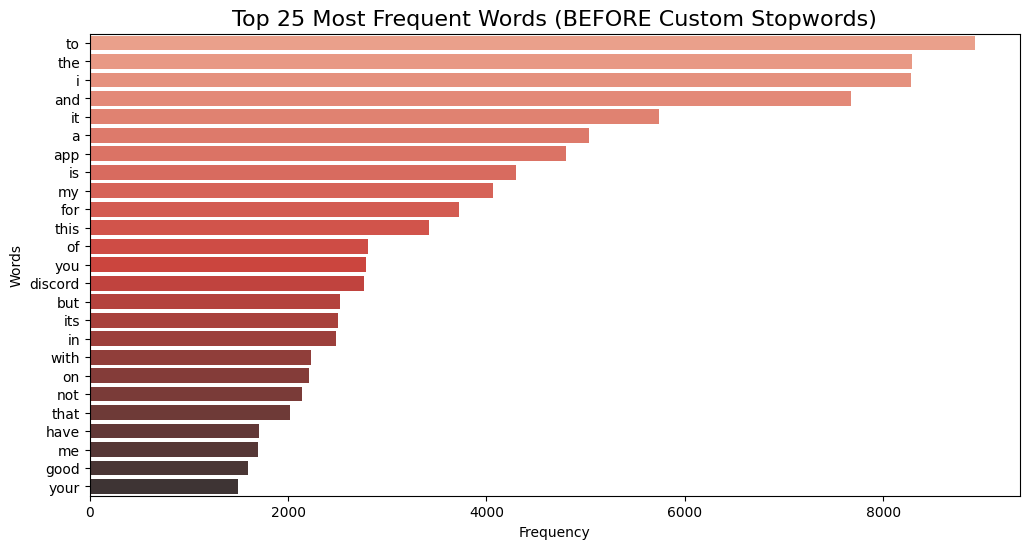

In [14]:
# Menghitung frekuensi dari teks asli (yang hanya di-lowercase)
df['tokens_before'] = df['content'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.split()
word_counts_before = df['tokens_before'].explode().value_counts().head(25)

plt.figure(figsize=(12, 6))
sns.barplot(x=word_counts_before.values, y=word_counts_before.index, palette='Reds_d', hue=word_counts_before.index, legend=False)
plt.title("Top 25 Most Frequent Words (BEFORE Custom Stopwords)", fontsize=16)
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

### **4.2. Top Words After Custom Stopwords**

Setelah daftar custom stopwords diterapkan, kita dapat melihat bahwa kata-kata yang tidak penting telah hilang, sehingga kata-kata yang mengandung nilai informasi (seperti "good", "love", "bad") mulai muncul ke permukaan.

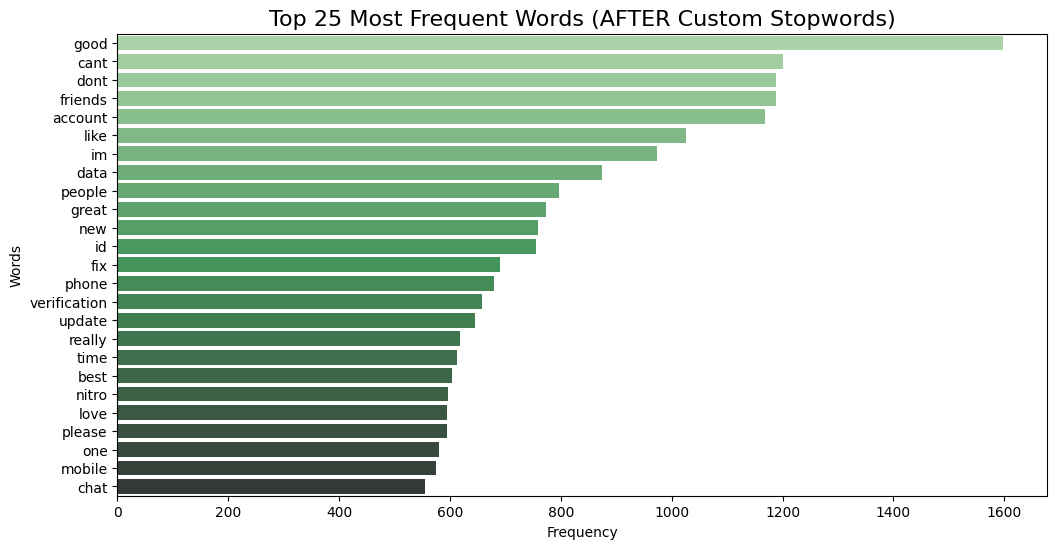

In [15]:
# Menggunakan kolom content_processed yang sudah melalui preprocessing_v2
df['tokens_after'] = df['content_processed'].apply(lambda x: str(x).split())
word_counts_after = df['tokens_after'].explode().value_counts().head(25)

plt.figure(figsize=(12, 6))
sns.barplot(x=word_counts_after.values, y=word_counts_after.index, palette='Greens_d', hue=word_counts_after.index, legend=False)
plt.title("Top 25 Most Frequent Words (AFTER Custom Stopwords)", fontsize=16)
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()